In [ ]:
import os

print(os.listdir('/content'))

['.config', 'archive.zip', 'sample_data']


# data_loader.py — Dataset Loading and Preprocessing


In [ ]:
import zipfile

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


Verify Dataset Structure

In [ ]:
import os

print(os.listdir('/content/dataset'))

['DUTS-TR', 'metadata.csv', 'DUTS-TE']


Check Training Folders

In [ ]:
train_path = "/content/dataset/DUTS-TR"

print(os.listdir(train_path))

['DUTS-TR-Image', 'DUTS-TR-Mask']


Explore folder structure

In [ ]:
import os

train_path = "/content/dataset/DUTS-TR"

print(os.listdir(train_path))

['DUTS-TR-Image', 'DUTS-TR-Mask']


Save folder paths

In [ ]:
image_path = "/content/dataset/DUTS-TR/DUTS-TR-Image"
mask_path = "/content/dataset/DUTS-TR/DUTS-TR-Mask"

print("Images:", len(os.listdir(image_path)))
print("Masks:", len(os.listdir(mask_path)))

Images: 10553
Masks: 10553


Look at sample filenames

In [ ]:
image_files = os.listdir(image_path)
mask_files = os.listdir(mask_path)

print(image_files[:5])
print(mask_files[:5])

['ILSVRC2013_val_00000755.jpg', 'n07718472_17689.jpg', 'ILSVRC2012_test_00095986.jpg', 'ILSVRC2012_test_00042416.jpg', 'n03764736_1632.jpg']
['n07745940_671.png', 'n03255030_8725.png', 'n03188531_20704.png', 'ILSVRC2012_test_00096991.png', 'ILSVRC2014_train_00059523.png']


Install visualization libraries

In [ ]:
import cv2
import matplotlib.pyplot as plt

Load one image and mask

In [ ]:
sample_image = image_files[0]

sample_mask = sample_image.replace('.jpg', '.png')

print(sample_image)
print(sample_mask)

ILSVRC2013_val_00000755.jpg
ILSVRC2013_val_00000755.png


Read the files

In [ ]:
image = cv2.imread(os.path.join(image_path, sample_image))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(os.path.join(mask_path, sample_mask), 0)

Display image and mask

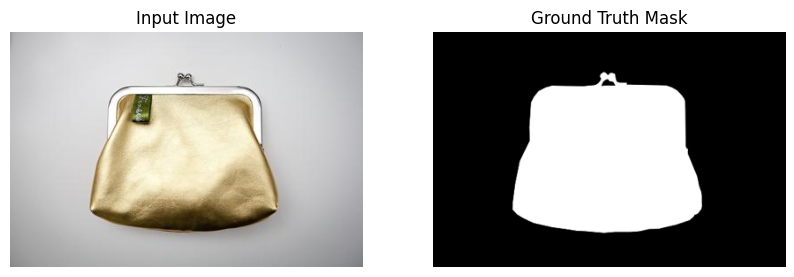

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

### Data Preprocessing

Import Required Libraries

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

Create Image and Mask Lists

In [ ]:
image_path = "/content/dataset/DUTS-TR/DUTS-TR-Image"
mask_path = "/content/dataset/DUTS-TR/DUTS-TR-Mask"

image_files = sorted(os.listdir(image_path))
mask_files = sorted(os.listdir(mask_path))

print("Total images:", len(image_files))
print("Total masks:", len(mask_files))

Total images: 10553
Total masks: 10553


Create Train/Validation Split

In [ ]:
# Create Train / Validation / Test Split

from sklearn.model_selection import train_test_split

# 70% train, 30% temp
train_images, temp_images = train_test_split(
    image_files,
    test_size=0.30,
    random_state=42
)

# Split remaining 30% into 15% validation and 15% test
val_images, test_images = train_test_split(
    temp_images,
    test_size=0.50,
    random_state=42
)

print("Training images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))

Training images: 7387
Validation images: 1583
Test images: 1583


Create Dataset Class

In [ ]:
class SODDataset(Dataset):
    def __init__(self, image_list, image_dir, mask_dir, image_size=128, augment=False):
        self.image_list = image_list
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_size = image_size
        self.augment = augment

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        image_name = self.image_list[idx]
        mask_name = image_name.replace(".jpg", ".png")

        image_full_path = os.path.join(self.image_dir, image_name)
        mask_full_path = os.path.join(self.mask_dir, mask_name)

        image = cv2.imread(image_full_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_full_path, 0)

        image = cv2.resize(image, (self.image_size, self.image_size))
        mask = cv2.resize(mask, (self.image_size, self.image_size))

        if self.augment:
            if random.random() > 0.5:
                image = cv2.flip(image, 1)
                mask = cv2.flip(mask, 1)

            if random.random() > 0.5:
                brightness = random.uniform(0.7, 1.3)
                image = np.clip(image * brightness, 0, 255).astype(np.uint8)

        image = image / 255.0
        mask = mask / 255.0

        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask

Create Dataset Objects

In [ ]:
train_dataset = SODDataset(train_images, image_path, mask_path, augment=True)
val_dataset = SODDataset(val_images, image_path, mask_path, augment=False)
test_dataset = SODDataset(test_images, image_path, mask_path, augment=False)

Create DataLoaders

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

Verify Shapes

In [ ]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

torch.Size([8, 3, 128, 128])
torch.Size([8, 1, 128, 128])


# sod_model.py — Model Architecture

Import PyTorch model tools

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

Create the CNN model

In [ ]:
class SODModel(nn.Module):
    def __init__(self):
        super(SODModel, self).__init__()


        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.enc3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )


        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU()
        )

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.ReLU()
        )

        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)

        x = self.dec1(x)
        x = self.dec2(x)
        x = self.dec3(x)

        return x

Create the model

In [ ]:
model = SODModel()

print(model)

SODModel(
  (enc1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (enc2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (enc3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dec1): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
  )
  (dec2): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
  )
  (dec3): Sequential(
    (0): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
    (1): Sigmoid()
  )
)


Check if GPU is available

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

model = model.to(device)

Using device: cpu


Test the model with one batch

In [ ]:
images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Mask shape:", masks.shape)

Input shape: torch.Size([8, 3, 128, 128])
Output shape: torch.Size([8, 1, 128, 128])
Mask shape: torch.Size([8, 1, 128, 128])


train the model

Set loss function and optimizer

In [ ]:
criterion = nn.BCELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

bce_loss = nn.BCELoss()

def iou_loss(pred, target, smooth=1e-6):
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    intersection = (pred * target).sum(dim=1)
    union = pred.sum(dim=1) + target.sum(dim=1) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return 1 - iou.mean()

def combined_loss(pred, target):
    return bce_loss(pred, target) + 0.5 * iou_loss(pred, target)

Train the model

In [ ]:
num_epochs = 25
train_losses = []
val_losses = []

best_val_loss = float("inf")
patience = 5
patience_counter = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = combined_loss(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = combined_loss(outputs, masks)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Validation Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "/content/best_sod_model.pth")
        print("Best model saved.")
    else:
        patience_counter += 1
        print(f"No improvement: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

Epoch [1/25]
Train Loss: 0.8840
Validation Loss: 0.8363
Best model saved.
Epoch [2/25]
Train Loss: 0.8334
Validation Loss: 0.8387
No improvement: 1/5
Epoch [3/25]
Train Loss: 0.8192
Validation Loss: 0.8138
Best model saved.
Epoch [4/25]
Train Loss: 0.8079
Validation Loss: 0.8022
Best model saved.
Epoch [5/25]
Train Loss: 0.7998
Validation Loss: 0.7952
Best model saved.
Epoch [6/25]
Train Loss: 0.7930
Validation Loss: 0.7937
Best model saved.
Epoch [7/25]
Train Loss: 0.7866
Validation Loss: 0.7873
Best model saved.
Epoch [8/25]
Train Loss: 0.7814
Validation Loss: 0.7827
Best model saved.
Epoch [9/25]
Train Loss: 0.7794
Validation Loss: 0.7700
Best model saved.
Epoch [10/25]
Train Loss: 0.7777
Validation Loss: 0.7670
Best model saved.
Epoch [11/25]
Train Loss: 0.7713
Validation Loss: 0.7802
No improvement: 1/5
Epoch [12/25]
Train Loss: 0.7712
Validation Loss: 0.7718
No improvement: 2/5
Epoch [13/25]
Train Loss: 0.7661
Validation Loss: 0.7731
No improvement: 3/5
Epoch [14/25]
Train Loss: 

Save the trained model

Model saved successfully!


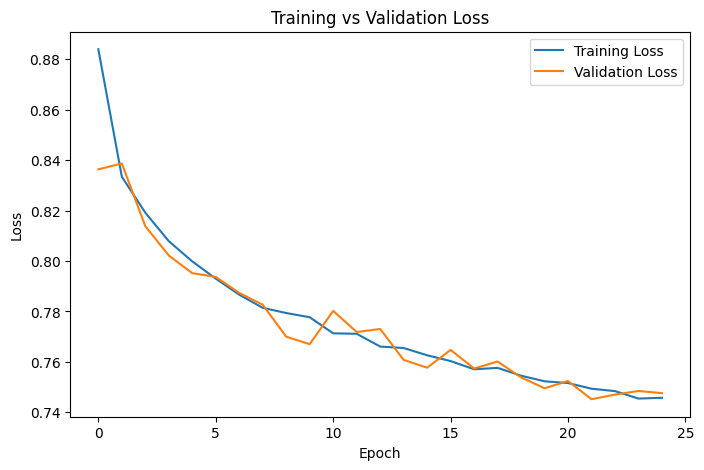

In [ ]:
torch.save(model.state_dict(), "/content/sod_model.pth")

print("Model saved successfully!")

# Plot training and validation loss

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

Visualize Predictions

In [ ]:
model.eval()

images, masks = next(iter(val_loader))

images = images.to(device)

with torch.no_grad():

    predictions = model(images)

images = images.cpu()
masks = masks.cpu()
predictions = predictions.cpu()

In [ ]:
def show_overlay(image, pred_mask, alpha=0.5):
    image_np = image.permute(1, 2, 0).numpy()
    mask_np = pred_mask.squeeze().numpy()

    overlay = image_np.copy()
    overlay[:, :, 0] = np.maximum(overlay[:, :, 0], mask_np)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image_np)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow((1 - alpha) * image_np + alpha * overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

Display Results

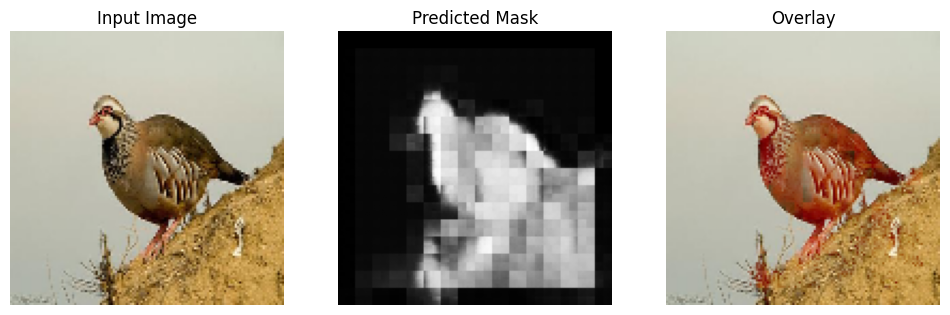

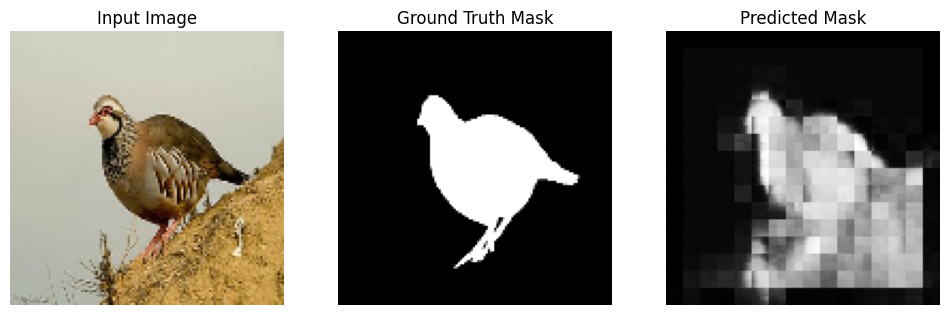

In [ ]:
idx = 0

show_overlay(images[idx], predictions[idx])

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(images[idx].permute(1,2,0))
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(masks[idx][0], cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(predictions[idx][0], cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

Convert Prediction Into Binary Mask

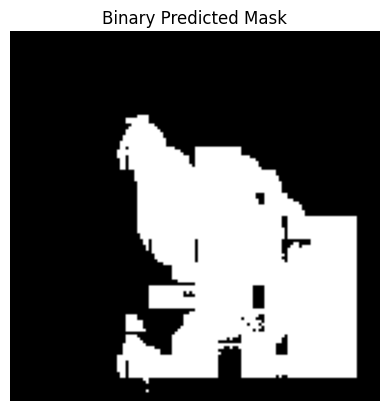

In [ ]:
binary_prediction = (predictions[idx][0] > 0.5).float()

plt.imshow(binary_prediction, cmap="gray")
plt.title("Binary Predicted Mask")
plt.axis("off")

plt.show()

Add IoU Metric

In [ ]:
def calculate_iou(pred, target, threshold=0.5):

    pred = (pred > threshold).float()
    target = (target > threshold).float()

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum() - intersection

    if union == 0:
        return 1.0

    return (intersection / union).item()


  # Precision, Recall, F1

def calculate_metrics(pred, target, threshold=0.5):

    pred = (pred > threshold).float()
    target = (target > threshold).float()

    tp = (pred * target).sum()

    fp = (pred * (1 - target)).sum()

    fn = ((1 - pred) * target).sum()

    precision = tp / (tp + fp + 1e-8)

    recall = tp / (tp + fn + 1e-8)

    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return precision.item(), recall.item(), f1.item()

Test IoU

In [ ]:
iou = calculate_iou(predictions[idx], masks[idx])

print("IoU:", iou)

IoU: 0.47671496868133545


# evaluate.py — Evaluation and Visualization

In [ ]:
# Evaluate on test set

model.eval()

total_iou = 0
total_precision = 0
total_recall = 0
total_f1 = 0

count = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        for i in range(images.size(0)):

            pred = outputs[i].cpu()
            target = masks[i].cpu()

            # IoU
            total_iou += calculate_iou(pred, target)

            # Precision, Recall, F1
            precision, recall, f1 = calculate_metrics(pred, target)

            total_precision += precision
            total_recall += recall
            total_f1 += f1

            count += 1

print("Average IoU:", total_iou / count)

print("Average Precision:", total_precision / count)

print("Average Recall:", total_recall / count)

print("Average F1 Score:", total_f1 / count)

Average IoU: 0.47039332315772864
Average Precision: 0.6235150212700881
Average Recall: 0.6937536985906981
Average F1 Score: 0.6077358758445318


Improved CNN Model

In [ ]:
class ImprovedSODModel(nn.Module):
    def __init__(self):
        super(ImprovedSODModel, self).__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(2)
        )

        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)

        x = self.dec1(x)
        x = self.dec2(x)
        x = self.dec3(x)

        return x

In [ ]:
# Create improved model

improved_model = ImprovedSODModel().to(device)

criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    improved_model.parameters(),
    lr=0.001
)

Train Improved Model

In [ ]:
num_epochs = 25

improved_train_losses = []
improved_val_losses = []

best_val_loss = float("inf")
patience = 5
patience_counter = 0

for epoch in range(num_epochs):

    improved_model.train()
    train_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = improved_model(images)

        loss = combined_loss(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    improved_model.eval()
    val_loss = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = improved_model(images)

            loss = combined_loss(outputs, masks)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    improved_train_losses.append(avg_train_loss)
    improved_val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Improved Train Loss: {avg_train_loss:.4f}")
    print(f"Improved Validation Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0

        torch.save(
            improved_model.state_dict(),
            "/content/best_improved_sod_model.pth"
        )

        print("Best improved model saved.")

    else:
        patience_counter += 1
        print(f"No improvement: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

Epoch [1/25]
Improved Train Loss: 0.8288
Improved Validation Loss: 0.8037
Best improved model saved.
Epoch [2/25]
Improved Train Loss: 0.7954
Improved Validation Loss: 0.8098
No improvement: 1/5
Epoch [3/25]
Improved Train Loss: 0.7857
Improved Validation Loss: 0.7983
Best improved model saved.
Epoch [4/25]
Improved Train Loss: 0.7759
Improved Validation Loss: 0.7746
Best improved model saved.
Epoch [5/25]
Improved Train Loss: 0.7733
Improved Validation Loss: 0.7595
Best improved model saved.
Epoch [6/25]
Improved Train Loss: 0.7664
Improved Validation Loss: 0.7770
No improvement: 1/5
Epoch [7/25]
Improved Train Loss: 0.7590
Improved Validation Loss: 0.7762
No improvement: 2/5
Epoch [8/25]
Improved Train Loss: 0.7532
Improved Validation Loss: 0.7598
No improvement: 3/5
Epoch [9/25]
Improved Train Loss: 0.7513
Improved Validation Loss: 0.7577
Best improved model saved.
Epoch [10/25]
Improved Train Loss: 0.7454
Improved Validation Loss: 0.7722
No improvement: 1/5
Epoch [11/25]
Improved T

In [ ]:
# Evaluate improved model

improved_model.eval()

total_iou = 0
total_precision = 0
total_recall = 0
total_f1 = 0

count = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = improved_model(images)

        for i in range(images.size(0)):

            pred = outputs[i].cpu()
            target = masks[i].cpu()

            total_iou += calculate_iou(pred, target)

            precision, recall, f1 = calculate_metrics(pred, target)

            total_precision += precision
            total_recall += recall
            total_f1 += f1

            count += 1

print("Improved Average IoU:", total_iou / count)

print("Improved Average Precision:", total_precision / count)

print("Improved Average Recall:", total_recall / count)

print("Improved Average F1 Score:", total_f1 / count)

Improved Average IoU: 0.5009249157642337
Improved Average Precision: 0.6702076774843588
Improved Average Recall: 0.6931840373780896
Improved Average F1 Score: 0.6348836726530509


In [ ]:
print(device)

# demo_notebook.ipynb — Demo

Saving 2d8cab5501c436f34db23953e23c0d67.jpg to 2d8cab5501c436f34db23953e23c0d67.jpg
Inference time: 0.0335 seconds


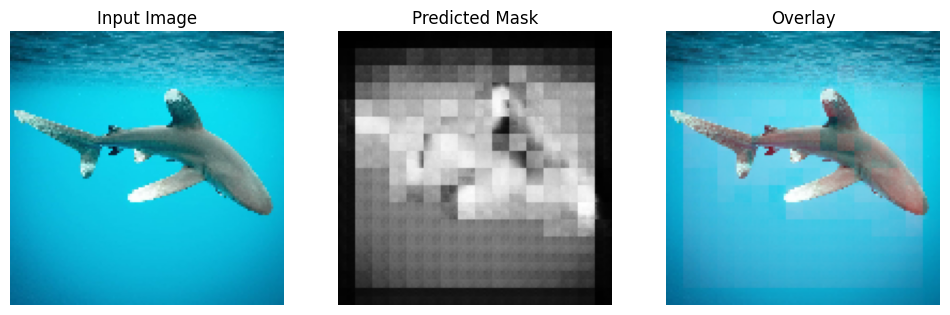

In [ ]:
from google.colab import files
import time

uploaded = files.upload()

improved_model.load_state_dict(
    torch.load("/content/best_improved_sod_model.pth", map_location=device)
)

improved_model.eval()

for filename in uploaded.keys():
    image = cv2.imread(filename)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image_resized = cv2.resize(image, (128, 128))
    image_normalized = image_resized / 255.0

    input_tensor = torch.tensor(
        image_normalized,
        dtype=torch.float32
    ).permute(2, 0, 1).unsqueeze(0).to(device)

    start_time = time.time()

    with torch.no_grad():
        prediction = improved_model(input_tensor)

    end_time = time.time()
    inference_time = end_time - start_time

    prediction = prediction.cpu()[0]
    image_tensor = torch.tensor(image_normalized, dtype=torch.float32).permute(2, 0, 1)

    print(f"Inference time: {inference_time:.4f} seconds")

    show_overlay(image_tensor, prediction)

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Baseline", "Improved"],
    "IoU": [0.4315, 0.4430],
    "Precision": [0.6521, 0.7025],
    "Recall": [0.5899, 0.5686],
    "F1 Score": [0.5646, 0.5739]
})

results

,Model,IoU,Precision,Recall,F1 Score
0,Baseline,0.4315,0.6521,0.5899,0.5646
1,Improved,0.4430,0.7025,0.5686,0.5739
